<a href="https://colab.research.google.com/github/zebanahvi/machine-learning-projects/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Author: Zeba Nahvi
06/20/2026
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from pandas import set_option
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from numpy import set_printoptions


filePath = '/content/'
filename = 'boston.csv'
names = ['crim','zn','indus','chas','nox','rm','age','dis','rad','tax','ptratio','black','lstat','medv']
data = read_csv(filePath + filename)
data1 = data.drop(data.columns[0], axis = 1) # to remove the extra index column


# save features as pandas dataframe for stepwise feature selection
X1 = data1.drop(data1.columns[13], axis = 1)
Y1 = data1.drop(data1.columns[0:13], axis = 1)

       crim    zn  indus  chas  nox   rm    age  dis  rad  tax  ptratio  black  lstat  medv
0   6.3e-03  18.0    2.3     0  0.5  6.6   65.2  4.1    1  296     15.3  396.9    5.0  24.0
1   2.7e-02   0.0    7.1     0  0.5  6.4   78.9  5.0    2  242     17.8  396.9    9.1  21.6
2   2.7e-02   0.0    7.1     0  0.5  7.2   61.1  5.0    2  242     17.8  392.8    4.0  34.7
3   3.2e-02   0.0    2.2     0  0.5  7.0   45.8  6.1    3  222     18.7  394.6    2.9  33.4
4   6.9e-02   0.0    2.2     0  0.5  7.1   54.2  6.1    3  222     18.7  396.9    5.3  36.2
5   3.0e-02   0.0    2.2     0  0.5  6.4   58.7  6.1    3  222     18.7  394.1    5.2  28.7
6   8.8e-02  12.5    7.9     0  0.5  6.0   66.6  5.6    5  311     15.2  395.6   12.4  22.9
7   1.4e-01  12.5    7.9     0  0.5  6.2   96.1  6.0    5  311     15.2  396.9   19.1  27.1
8   2.1e-01  12.5    7.9     0  0.5  5.6  100.0  6.1    5  311     15.2  386.6   29.9  16.5
9   1.7e-01  12.5    7.9     0  0.5  6.0   85.9  6.6    5  311     15.2  386.7  

<Figure size 640x480 with 0 Axes>

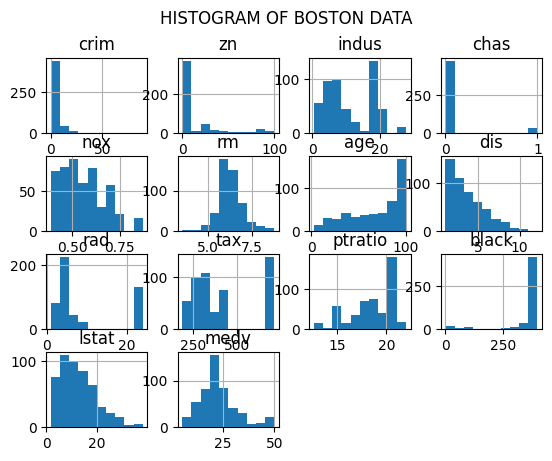

            crim       zn    indus     chas      nox       rm      age      dis      rad      tax  \
crim     1.0e+00 -2.0e-01  4.1e-01 -5.6e-02  4.2e-01 -2.2e-01  3.5e-01 -3.8e-01  6.3e-01  5.8e-01   
zn      -2.0e-01  1.0e+00 -5.3e-01 -4.3e-02 -5.2e-01  3.1e-01 -5.7e-01  6.6e-01 -3.1e-01 -3.1e-01   
indus    4.1e-01 -5.3e-01  1.0e+00  6.3e-02  7.6e-01 -3.9e-01  6.4e-01 -7.1e-01  6.0e-01  7.2e-01   
chas    -5.6e-02 -4.3e-02  6.3e-02  1.0e+00  9.1e-02  9.1e-02  8.7e-02 -9.9e-02 -7.4e-03 -3.6e-02   
nox      4.2e-01 -5.2e-01  7.6e-01  9.1e-02  1.0e+00 -3.0e-01  7.3e-01 -7.7e-01  6.1e-01  6.7e-01   
rm      -2.2e-01  3.1e-01 -3.9e-01  9.1e-02 -3.0e-01  1.0e+00 -2.4e-01  2.1e-01 -2.1e-01 -2.9e-01   
age      3.5e-01 -5.7e-01  6.4e-01  8.7e-02  7.3e-01 -2.4e-01  1.0e+00 -7.5e-01  4.6e-01  5.1e-01   
dis     -3.8e-01  6.6e-01 -7.1e-01 -9.9e-02 -7.7e-01  2.1e-01 -7.5e-01  1.0e+00 -4.9e-01 -5.3e-01   
rad      6.3e-01 -3.1e-01  6.0e-01 -7.4e-03  6.1e-01 -2.1e-01  4.6e-01 -4.9e-01  1.0e+00  9

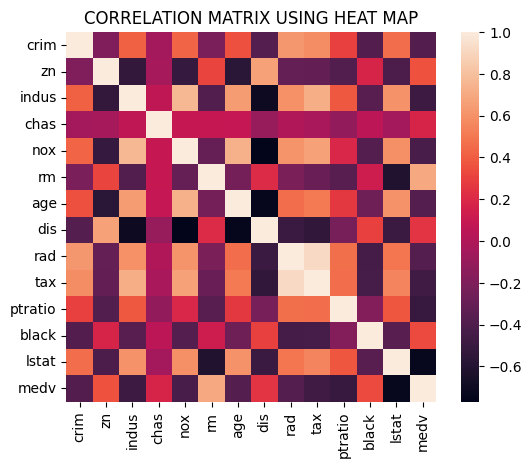

<Figure size 640x480 with 0 Axes>

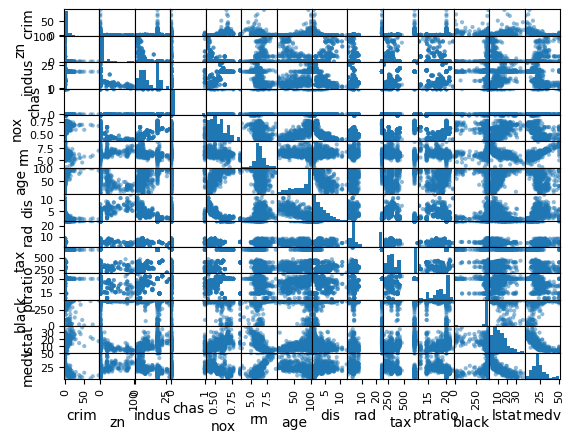

In [ ]:
# separate features and responses into two different arrays
Y = Y1.values # 1D
X = X1.values # 2D


# Exploratory data analysis using correlation and scatter plot

peek = data1.head(20) # look at first 20 rows of data
print(peek)


# descriptive statistics
set_option('display.width', 100)
set_option('display.precision',1)
description = data1.describe()
print(description)


# visual display of distribution
plt.figure() # new plot
data1.hist()
plt.suptitle("HISTOGRAM OF BOSTON DATA")
plt.show()


# correlation heat map, pay attention to correlation
# between all predicators/features and each predictor and output
plt.figure()
corMat = data1.corr(method='pearson')
print(corMat)
# plot correlation matrix as a heat map
sns.heatmap(corMat, square=True)
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title("CORRELATION MATRIX USING HEAT MAP")
plt.show()


# scatter plot of all data
plt.figure()
plt.suptitle("SCATTER MATRIX")
scatter_matrix(data1)
plt.show()

In [ ]:
# DETERMINATION OF DOMINANT FEATURES
# Method 1: Recursive Model Elimination - pruning

num_features = 6
model = LinearRegression()
rfe = RFE(model, n_features_to_select=num_features)
fit = rfe.fit(X, Y)
print("Num Features: ", fit.n_features_)
print("Selected Features: ", X1.columns[fit.support_])
print("Feature Ranking: ", fit.ranking_)
# calculate the score for selected features
score = rfe.score(X,Y)
print("Model Score with selected features is: ", score)

Num Features:  6
Selected Features:  Index(['chas', 'nox', 'rm', 'dis', 'ptratio', 'lstat'], dtype='object')
Feature Ranking:  [3 5 4 1 1 1 8 1 2 6 1 7 1]
Model Score with selected features is:  0.7157742117396082


In [ ]:
# Method 2: Stepwise Forward-Backward Selection - based on p-value
def stepwise_selection(X, y,
                       initial_list = [],
                       threshold_in = 0.01,
                       threshold_out = 0.05,
                       verbose = True):
  included = list(initial_list)
  while True:
    changed = False
    # forward step
    excluded = list(set(X.columns)-set(included))
    new_pval = pd.Series(index=excluded)
    for new_column in excluded:
      model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
      new_pval[new_column] = model.pvalues[new_column]
    best_pval = new_pval.min()
    if best_pval < threshold_in:
      best_feature = new_pval.idxmin()
      included.append(best_feature)
      changed = True
      if verbose:
        print('Add {:30} with p-value {:.6}'.format(best_feature, best_pval))

    # backward step
    model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
    # use all coefs except intercept
    pvalues = model.pvalues.iloc[1:]
    worst_pval = pvalues.max()
    if worst_pval > threshold_out:
      changed = True
      worst_feature = pvalues.idxmax()
      included.remove(worst_feature)
      if verbose:
        print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
      if not changed:
        break
  return included
result = stepwise_selection(X1, Y)
print('Resulting Features: ')
print(result)

Add lstat                          with p-value 5.0811e-88
Add rm                             with p-value 3.47226e-27
Add ptratio                        with p-value 1.64466e-14
Add dis                            with p-value 1.66847e-05
Add nox                            with p-value 5.48815e-08
Add chas                           with p-value 0.000265473
Add black                          with p-value 0.000771946
Add zn                             with p-value 0.00465162


KeyboardInterrupt: 

In [ ]:
# Standardizing the Data
X1names = X1.columns

scaler1 = StandardScaler().fit(X1)
rescaledX1 = scaler1.transform(X1)

# making a new data frame with the standardized data
dataStandDf = pd.DataFrame(rescaledX1, columns = X1names)
dataStandDf['medv'] = Y1.values

            crim       zn    indus     chas      nox       rm      age      dis      rad      tax  \
crim     1.0e+00 -2.0e-01  4.1e-01 -5.6e-02  4.2e-01 -2.2e-01  3.5e-01 -3.8e-01  6.3e-01  5.8e-01   
zn      -2.0e-01  1.0e+00 -5.3e-01 -4.3e-02 -5.2e-01  3.1e-01 -5.7e-01  6.6e-01 -3.1e-01 -3.1e-01   
indus    4.1e-01 -5.3e-01  1.0e+00  6.3e-02  7.6e-01 -3.9e-01  6.4e-01 -7.1e-01  6.0e-01  7.2e-01   
chas    -5.6e-02 -4.3e-02  6.3e-02  1.0e+00  9.1e-02  9.1e-02  8.7e-02 -9.9e-02 -7.4e-03 -3.6e-02   
nox      4.2e-01 -5.2e-01  7.6e-01  9.1e-02  1.0e+00 -3.0e-01  7.3e-01 -7.7e-01  6.1e-01  6.7e-01   
rm      -2.2e-01  3.1e-01 -3.9e-01  9.1e-02 -3.0e-01  1.0e+00 -2.4e-01  2.1e-01 -2.1e-01 -2.9e-01   
age      3.5e-01 -5.7e-01  6.4e-01  8.7e-02  7.3e-01 -2.4e-01  1.0e+00 -7.5e-01  4.6e-01  5.1e-01   
dis     -3.8e-01  6.6e-01 -7.1e-01 -9.9e-02 -7.7e-01  2.1e-01 -7.5e-01  1.0e+00 -4.9e-01 -5.3e-01   
rad      6.3e-01 -3.1e-01  6.0e-01 -7.4e-03  6.1e-01 -2.1e-01  4.6e-01 -4.9e-01  1.0e+00  9

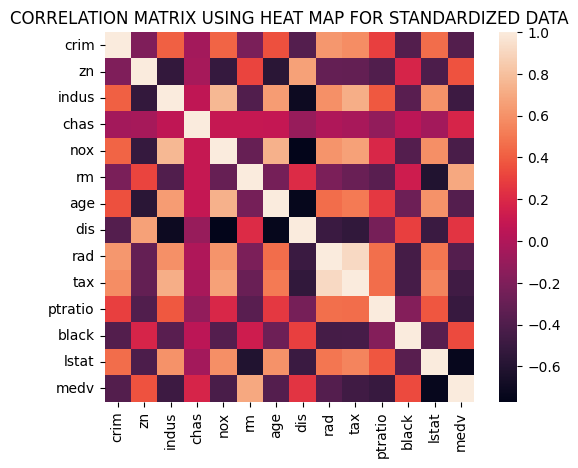

<Figure size 640x480 with 0 Axes>

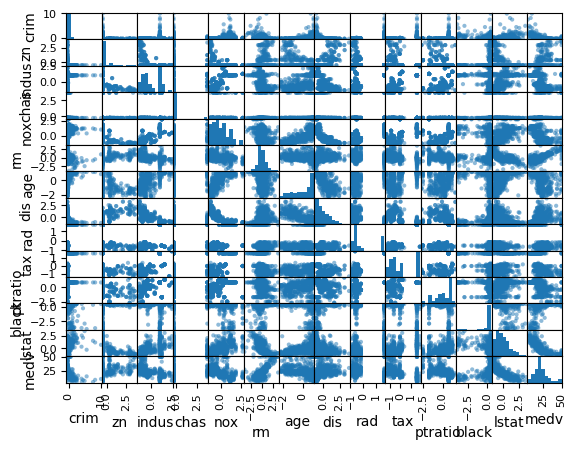

In [ ]:
# Matrices for the Standardized Data Features

# 1) Correlation heat map
plt.figure()
corMatStand = dataStandDf.corr(method='pearson')
print(corMatStand)
# plot correlation matrix as a heat map
sns.heatmap(corMatStand, square=True)
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title("CORRELATION MATRIX USING HEAT MAP FOR STANDARDIZED DATA")
plt.show()


# 2) Scatter matrix
plt.figure()
plt.suptitle("SCATTER MATRIX FOR STANDARDIZED DATA")
scatter_matrix(dataStandDf)
plt.show()

DESCRIPTIVE STATS OF THE STANDARDIZED DATA:
          crim       zn    indus     chas      nox       rm      age      dis      rad    tax  \
count  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  506.0   
mean  -1.1e-16  7.9e-17  2.1e-16 -3.5e-17 -2.0e-16 -1.1e-16 -1.5e-16 -8.4e-17 -1.1e-16    0.0   
std    1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00  1.0e+00    1.0   
min   -4.2e-01 -4.9e-01 -1.6e+00 -2.7e-01 -1.5e+00 -3.9e+00 -2.3e+00 -1.3e+00 -9.8e-01   -1.3   
25%   -4.1e-01 -4.9e-01 -8.7e-01 -2.7e-01 -9.1e-01 -5.7e-01 -8.4e-01 -8.1e-01 -6.4e-01   -0.8   
50%   -3.9e-01 -4.9e-01 -2.1e-01 -2.7e-01 -1.4e-01 -1.1e-01  3.2e-01 -2.8e-01 -5.2e-01   -0.5   
75%    7.4e-03  4.9e-02  1.0e+00 -2.7e-01  6.0e-01  4.8e-01  9.1e-01  6.6e-01  1.7e+00    1.5   
max    9.9e+00  3.8e+00  2.4e+00  3.7e+00  2.7e+00  3.6e+00  1.1e+00  4.0e+00  1.7e+00    1.8   

       ptratio    black    lstat   medv  
count  5.1e+02  5.1e+02  5.1e+02  506.0 

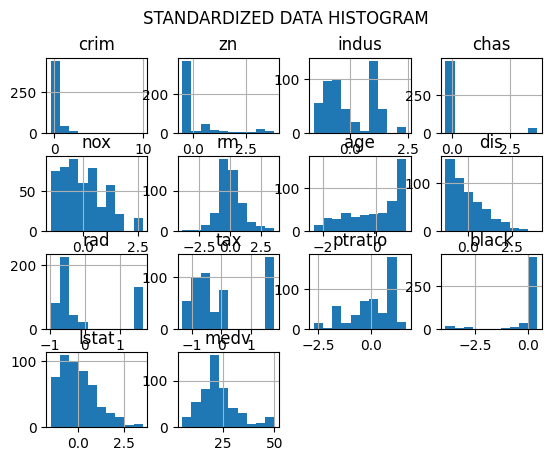

Method 1 - RECURSIVE FEATURE ELIMINATION
Num Features:  6
Selected Features:  Index(['nox', 'rm', 'dis', 'rad', 'ptratio', 'lstat'], dtype='object')
Feature Ranking:  [3 4 7 6 1 1 8 1 1 2 1 5 1]
Model Score with selected features is:  0.7093412846769827
Method 2 - STEPWISE SELECTION
Add lstat                          with p-value 5.0811e-88
Add rm                             with p-value 3.47226e-27
Add ptratio                        with p-value 1.64466e-14
Add dis                            with p-value 1.66847e-05
Add nox                            with p-value 5.48815e-08
Add chas                           with p-value 0.000265473
Add black                          with p-value 0.000771946
Add zn                             with p-value 0.00465162


KeyboardInterrupt: 

In [ ]:
# Working with Standardized Data

# 3) descriptive statistics: mean, max, min, count, 25th percentile, 50th percentile
set_option('display.width', 100)
set_option('display.precision',1)
descriptionStand = dataStandDf.describe()
print(f'DESCRIPTIVE STATS OF THE STANDARDIZED DATA:\n{descriptionStand}')

# 4) Histogram
dataStandDf.hist()
plt.suptitle("STANDARDIZED DATA HISTOGRAM")
plt.show()

# 5) Selecting Best Features

print("Method 1 - RECURSIVE FEATURE ELIMINATION")
#num_features = 6
#model = LinearRegression()
rfe = RFE(model, n_features_to_select=num_features)
fit = rfe.fit(rescaledX1, Y)
print("Num Features: ", fit.n_features_)
print("Selected Features: ", X1names[fit.support_])
print("Feature Ranking: ", fit.ranking_)
# calculate the score for selected features
score = rfe.score(rescaledX1,Y)
print("Model Score with selected features is: ", score)

print("Method 2 - STEPWISE SELECTION")
df_rescaledX1 = pd.DataFrame(rescaledX1, columns=X1names)
resultStand = stepwise_selection(df_rescaledX1, Y)
print('Resulting Features: ')
print(resultStand)


            crim       zn    indus     chas      nox       rm      age      dis      rad      tax  \
crim     1.0e+00 -2.1e-01  2.5e-01 -6.3e-02 -8.2e-02 -4.9e-01  8.7e-02 -4.2e-01  6.1e-01  5.5e-01   
zn      -2.1e-01  1.0e+00 -5.2e-01 -1.9e-02 -3.0e-01  3.9e-01 -4.8e-01  6.4e-01 -3.1e-01 -3.3e-01   
indus    2.5e-01 -5.2e-01  1.0e+00  8.2e-02  4.1e-01 -4.5e-01  4.5e-01 -6.3e-01  2.8e-01  4.6e-01   
chas    -6.3e-02 -1.9e-02  8.2e-02  1.0e+00  1.5e-01  1.0e-01  1.2e-01 -5.2e-02 -4.0e-02 -7.5e-02   
nox     -8.2e-02 -3.0e-01  4.1e-01  1.5e-01  1.0e+00  2.5e-01  6.0e-01 -2.6e-01 -2.1e-01 -1.2e-01   
rm      -4.9e-01  3.9e-01 -4.5e-01  1.0e-01  2.5e-01  1.0e+00 -3.9e-02  5.8e-01 -7.0e-01 -8.0e-01   
age      8.7e-02 -4.8e-01  4.5e-01  1.2e-01  6.0e-01 -3.9e-02  1.0e+00 -4.9e-01  2.5e-02  7.9e-02   
dis     -4.2e-01  6.4e-01 -6.3e-01 -5.2e-02 -2.6e-01  5.8e-01 -4.9e-01  1.0e+00 -5.6e-01 -6.2e-01   
rad      6.1e-01 -3.1e-01  2.8e-01 -4.0e-02 -2.1e-01 -7.0e-01  2.5e-02 -5.6e-01  1.0e+00  8

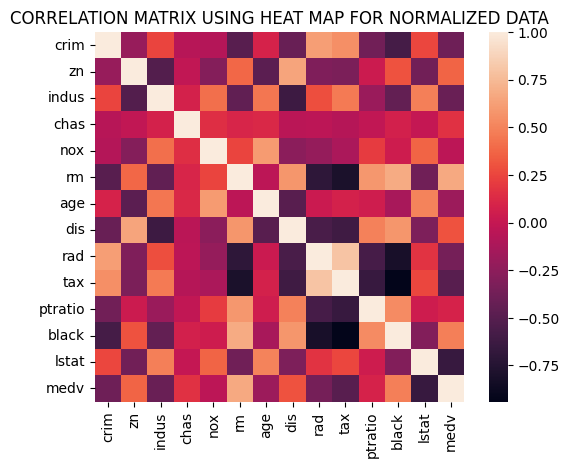

<Figure size 640x480 with 0 Axes>

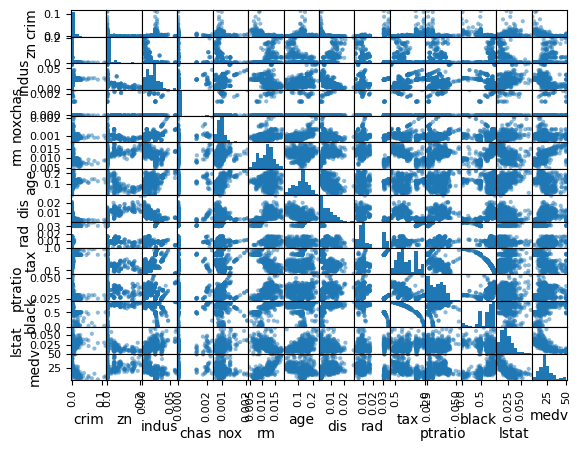

DESCRIPTION STATISTICS OF THE NORMALIZED DATA:
          crim       zn    indus     chas      nox       rm      age      dis      rad    tax  \
count  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  5.1e+02  506.0   
mean   5.1e-03  2.3e-02  1.9e-02  1.3e-04  9.9e-04  1.2e-02  1.2e-01  7.3e-03  1.5e-02    0.7   
std    1.2e-02  4.7e-02  1.1e-02  4.8e-04  1.9e-04  2.7e-03  4.8e-02  4.6e-03  1.1e-02    0.2   
min    1.3e-05  0.0e+00  9.6e-04  0.0e+00  6.6e-04  4.7e-03  6.4e-03  1.5e-03  1.7e-03    0.4   
25%    1.6e-04  0.0e+00  1.1e-02  0.0e+00  8.7e-04  9.4e-03  8.6e-02  3.3e-03  7.9e-03    0.6   
50%    5.0e-04  0.0e+00  1.7e-02  0.0e+00  9.7e-04  1.2e-02  1.3e-01  6.4e-03  1.0e-02    0.7   
75%    5.2e-03  2.5e-02  2.4e-02  0.0e+00  1.1e-03  1.3e-02  1.6e-01  1.1e-02  3.1e-02    0.9   
max    1.1e-01  2.1e-01  6.1e-02  2.4e-03  2.1e-03  1.8e-02  2.4e-01  2.8e-02  3.6e-02    1.0   

       ptratio    black    lstat   medv  
count  5.1e+02  5.1e+02  5.1e+02  506

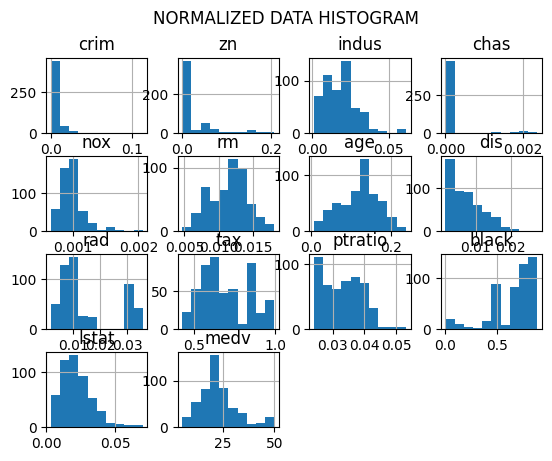

Method 1 - RECURSIVE FEATURE ELIMINATION
Num Features:  6
Selected Features:  Index(['chas', 'nox', 'rm', 'dis', 'ptratio', 'lstat'], dtype='object')
Feature Ranking:  [2 4 5 1 1 1 8 1 3 7 1 6 1]
Model Score with selected features is:  0.72156629124184
Method 2 - STEPWISE SELECTION
Add rm                             with p-value 1.58696e-67
Add lstat                          with p-value 2.14089e-46
Add ptratio                        with p-value 3.68347e-21
Add dis                            with p-value 1.07267e-05
Add black                          with p-value 8.35115e-06
Add nox                            with p-value 6.21776e-05
Add chas                           with p-value 0.00136365
Add crim                           with p-value 0.00407298
Add rad                            with p-value 0.00180981


In [ ]:
# Normalizing the Data

scaler = Normalizer().fit(X1)
normalizedX = scaler.transform(X1)

# you can make a new data frame with the normalized data
dataNormDf = pd.DataFrame(normalizedX,columns = X1names)
dataNormDf['medv'] = Y1.values

# Matrices for the Normalized Data Features

# 1) Correlation heat map
plt.figure()
corMatNorm = dataNormDf.corr(method='pearson')
print(corMatNorm)
# plot correlation matrix as a heat map
sns.heatmap(corMatNorm, square=True)
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title("CORRELATION MATRIX USING HEAT MAP FOR NORMALIZED DATA")
plt.show()

# 2) Scatter matrix
plt.figure()
plt.suptitle("SCATTER MATRIX FOR STANDARDIZED DATA")
scatter_matrix(dataNormDf)
plt.show()

# Working with Normalized Data

# 3) Descriptive Statistics
set_option('display.width', 100)
set_option('display.precision',1)
descriptionNorm = dataNormDf.describe()
print(f'DESCRIPTION STATISTICS OF THE NORMALIZED DATA:\n{descriptionNorm}')

# 4) Histogram
# we look at the distribution of data
dataNormDf.hist()
plt.suptitle("NORMALIZED DATA HISTOGRAM")
plt.show()

# 5) Selecting best features

print("Method 1 - RECURSIVE FEATURE ELIMINATION")
#num_features = 6
#model = LinearRegression()
rfe = RFE(model, n_features_to_select=num_features)
fit = rfe.fit(normalizedX, Y)
print("Num Features: ", fit.n_features_)
print("Selected Features: ", X1names[fit.support_])
print("Feature Ranking: ", fit.ranking_)
# calculate the score for selected features
score = rfe.score(normalizedX,Y)
print("Model Score with selected features is: ", score)

print("Method 2 - STEPWISE SELECTION")
df_normalizedX = pd.DataFrame(normalizedX, columns=X1names)
resultNorm = stepwise_selection(df_normalizedX, Y)
print('Resulting Features: ')
print(resultNorm)